# Exercice 5 - Classification sur le dataset fourni

## Présentation du dataset

Le dataset est stocké dans `FTML/Project/data/classification/` sous forme de quatre fichiers `.npy` :
`X_train`, `X_test` (2000 lignes, 30 colonnes chacun) et `y_train`, `y_test` (2000 étiquettes chacun).
Il s'agit d'un problème de **classification binaire** (classes 0 et 1) à partir de 30 variables numériques.

## Objectif

Obtenir une accuracy supérieure à 0.85 sur le jeu de test, ce dernier ne devant jamais servir pendant
l'entraînement (le réglage des hyperparamètres se fait par validation croisée sur le seul jeu
d'entraînement). On compare plusieurs estimateurs parmi ceux indiqués dans le sujet
(`LogisticRegression`, `KNeighborsClassifier`, `SVC`).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, validation_curve
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

RANDOM_STATE = 0

In [2]:
X_train = np.load("X_train.npy")
X_test = np.load("X_test.npy")
y_train = np.load("y_train.npy").ravel()
y_test = np.load("y_test.npy").ravel()

print("X_train :", X_train.shape, "| X_test :", X_test.shape)
print("valeurs manquantes :", np.isnan(X_train).sum() + np.isnan(X_test).sum())

X_train : (2000, 30) | X_test : (2000, 30)
valeurs manquantes : 0


## Analyse exploratoire

On regarde d'abord l'équilibre des classes, puis on projette les données en 2D par PCA pour visualiser
la séparabilité des deux classes.

In [3]:
for name, y in [("train", y_train), ("test", y_test)]:
    vals, counts = np.unique(y, return_counts=True)
    prop = counts / counts.sum()
    print(f"{name}: classe 0 = {counts[0]} ({prop[0]:.1%}), classe 1 = {counts[1]} ({prop[1]:.1%})")
print(f"\nbaseline (toujours la classe majoritaire du test) = {max(np.mean(y_test==0), np.mean(y_test==1)):.3f}")

train: classe 0 = 1019 (50.9%), classe 1 = 981 (49.0%)
test: classe 0 = 1118 (55.9%), classe 1 = 882 (44.1%)

baseline (toujours la classe majoritaire du test) = 0.559


Les classes sont proches de l'équilibre (train ~51/49, test ~56/44), donc l'accuracy est un score
pertinent. La baseline naïve (prédire toujours la classe majoritaire) atteint environ 0.56 : c'est le
seuil minimal qu'un modèle utile doit dépasser.

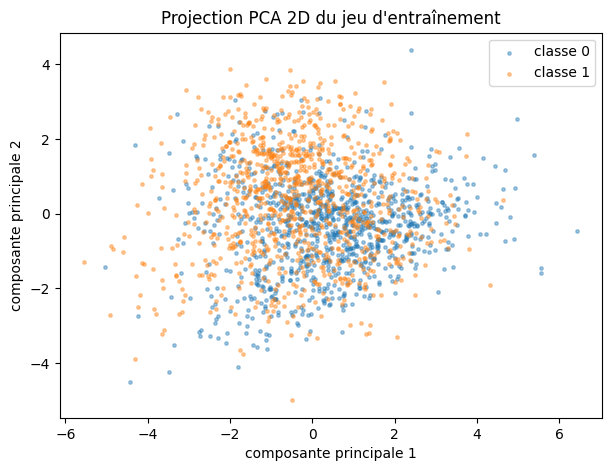

In [4]:
scaler_viz = StandardScaler().fit(X_train)
X_pca = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(scaler_viz.transform(X_train))

fig, ax = plt.subplots(figsize=(7, 5))
for cls, color in [(0, "tab:blue"), (1, "tab:orange")]:
    m = y_train == cls
    ax.scatter(X_pca[m, 0], X_pca[m, 1], s=6, alpha=0.4, color=color, label=f"classe {cls}")
ax.set_xlabel("composante principale 1")
ax.set_ylabel("composante principale 2")
ax.set_title("Projection PCA 2D du jeu d'entraînement")
ax.legend()
plt.show()

Les deux classes se recouvrent très largement : aucune séparation nette n'apparaît. Cette superposition
laisse anticiper qu'aucun modèle ne pourra atteindre une accuracy proche de 1, et qu'une frontière non
linéaire sera nécessaire pour tirer parti du peu de signal disponible.

## Préparation des données

On standardise les variables (moyenne 0, écart-type 1). Les moyennes et écarts-types sont calculés sur le seul jeu d'entraînement, puis appliqués au test : aucune information du test ne participe à
l'entraînement. La standardisation est nécessaire pour les trois modèles comparés, qui reposent tous sur
des distances ou des produits scalaires sensibles à l'échelle des variables. Elle est intégrée dans un
`Pipeline` pour être ré-estimée à chaque pli de validation croisée.

## Comparaison de trois modèles

On compare trois estimateurs de familles différentes, chacun avec ses hyperparamètres réglés par
validation croisée à 5 plis sur le train :

- **Régression logistique** : frontière linéaire, sert de référence.
- **K plus proches voisins** : frontière non linéaire fondée sur le voisinage local.
- **SVC à noyau RBF** : frontière non linéaire fondée sur des noyaux, souvent performant en dimension modérée.

Pour chaque modèle on reporte le meilleur hyperparamètre, l'accuracy de validation croisée, puis
l'accuracy sur le train et sur le test.

In [5]:
logreg = GridSearchCV(
    Pipeline([("sc", StandardScaler()), ("clf", LogisticRegression(max_iter=5000))]),
    {"clf__C": np.logspace(-2, 2, 10)},
    cv=5, scoring="accuracy", n_jobs=-1)
logreg.fit(X_train, y_train)
print("Régression logistique  -> meilleur C =", round(logreg.best_params_["clf__C"], 4),
      "| accuracy CV =", round(logreg.best_score_, 4))

Régression logistique  -> meilleur C = 0.0774 | accuracy CV = 0.7155


In [6]:
knn = GridSearchCV(
    Pipeline([("sc", StandardScaler()), ("clf", KNeighborsClassifier())]),
    {"clf__n_neighbors": [11, 21, 31, 51], "clf__weights": ["uniform", "distance"]},
    cv=5, scoring="accuracy", n_jobs=-1)
knn.fit(X_train, y_train)
print("K plus proches voisins -> meilleurs params =", knn.best_params_,
      "| accuracy CV =", round(knn.best_score_, 4))

K plus proches voisins -> meilleurs params = {'clf__n_neighbors': 31, 'clf__weights': 'uniform'} | accuracy CV = 0.747


In [7]:
svc = GridSearchCV(
    Pipeline([("sc", StandardScaler()), ("clf", SVC())]),
    {"clf__C": [1, 5, 10, 50], "clf__gamma": ["scale", 0.02, 0.05, 0.1, 0.2]},
    cv=5, scoring="accuracy", n_jobs=-1)
svc.fit(X_train, y_train)
print("SVC (noyau RBF)        -> meilleurs params =", svc.best_params_,
      "| accuracy CV =", round(svc.best_score_, 4))

SVC (noyau RBF)        -> meilleurs params = {'clf__C': 5, 'clf__gamma': 0.1} | accuracy CV = 0.77


### Résultats : accuracy train et test

In [8]:
models = [("Régression logistique", logreg), ("K plus proches voisins", knn), ("SVC (RBF)", svc)]

print(f"{'Modèle':<24}{'CV':>8}{'train':>9}{'test':>9}")
scores = {}
for name, model in models:
    acc_tr = accuracy_score(y_train, model.predict(X_train))
    acc_te = accuracy_score(y_test, model.predict(X_test))
    scores[name] = (model.best_score_, acc_tr, acc_te)
    print(f"{name:<24}{model.best_score_:>8.3f}{acc_tr:>9.3f}{acc_te:>9.3f}")

Modèle                        CV    train     test
Régression logistique      0.716    0.721    0.745


K plus proches voisins     0.747    0.767    0.778


SVC (RBF)                  0.770    1.000    0.800


On visualise ces accuracy train / test, puis on regarde plus en détail le meilleur modèle (SVC) :
la courbe de son accuracy en fonction de l'hyperparamètre `gamma`, et sa matrice de confusion sur le test.

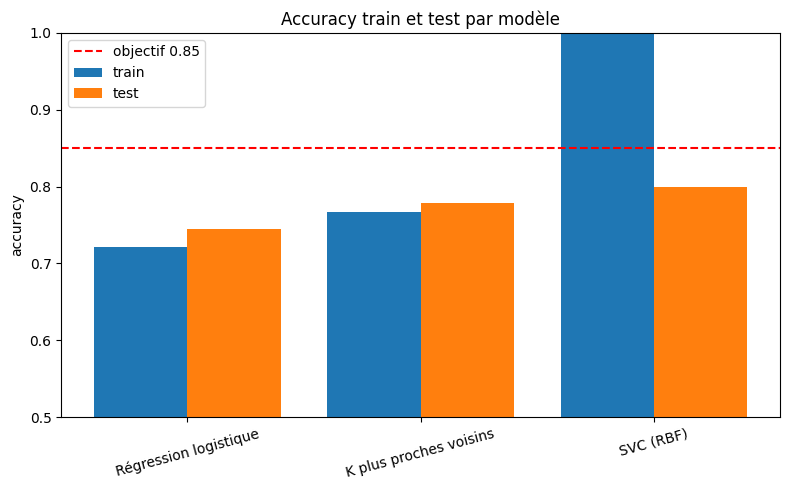

In [9]:
names = list(scores.keys())
tr = [scores[n][1] for n in names]
te = [scores[n][2] for n in names]

x = np.arange(len(names))
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - 0.2, tr, 0.4, label="train")
ax.bar(x + 0.2, te, 0.4, label="test")
ax.axhline(0.85, color="red", linestyle="--", label="objectif 0.85")
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=15)
ax.set_ylabel("accuracy")
ax.set_ylim(0.5, 1.0)
ax.set_title("Accuracy train et test par modèle")
ax.legend()
plt.tight_layout()
plt.show()

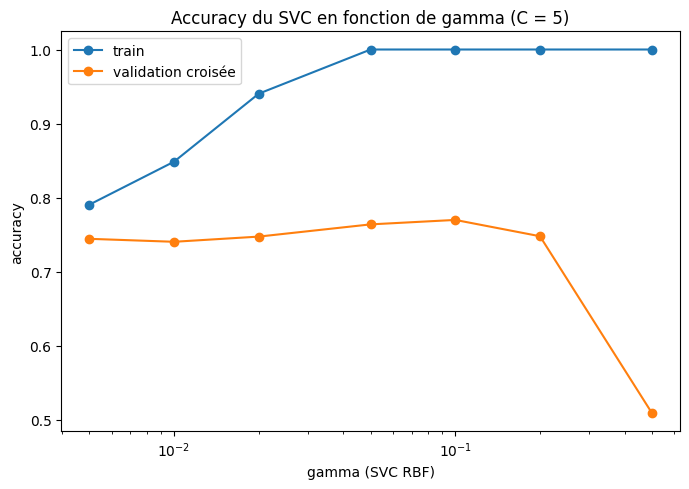

In [10]:
best_C = svc.best_params_["clf__C"]
gammas = [0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.5]
train_sc, cv_sc = validation_curve(
    Pipeline([("sc", StandardScaler()), ("clf", SVC(C=best_C))]),
    X_train, y_train, param_name="clf__gamma", param_range=gammas,
    cv=5, scoring="accuracy", n_jobs=-1)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(gammas, train_sc.mean(axis=1), "o-", label="train")
ax.plot(gammas, cv_sc.mean(axis=1), "o-", label="validation croisée")
ax.set_xscale("log")
ax.set_xlabel("gamma (SVC RBF)")
ax.set_ylabel("accuracy")
ax.set_title(f"Accuracy du SVC en fonction de gamma (C = {best_C})")
ax.legend()
plt.tight_layout()
plt.show()

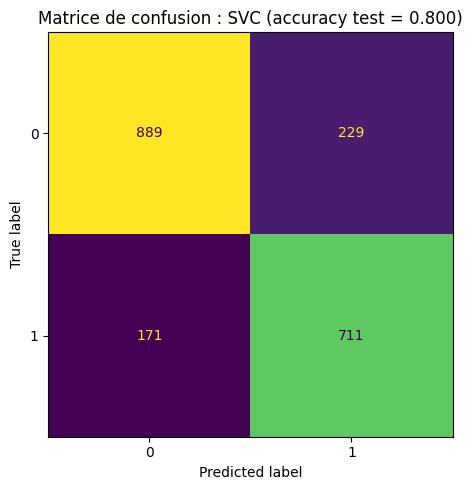

In [11]:
y_pred = svc.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay(cm, display_labels=[0, 1]).plot(ax=ax, colorbar=False)
ax.set_title(f"Matrice de confusion : SVC (accuracy test = {accuracy_score(y_test, y_pred):.3f})")
plt.tight_layout()
plt.show()

## Discussion

**Pertinence des modèles.** Le SVC à noyau RBF obtient la meilleure accuracy de test (~0.80), devant les
K plus proches voisins (~0.78) et la régression logistique (~0.74). Que les deux modèles à frontière non
linéaire (SVC et KNN) dépassent la régression logistique confirme que la frontière entre les classes
n'est pas linéaire.

**Compromis biais-variance.** Au `gamma` retenu par validation croisée, le SVC atteint 1.0 d'accuracy
sur le train mais seulement 0.80 sur le test. La courbe d'accuracy en fonction de `gamma` illustre ce
compromis : lorsque `gamma` augmente, l'accuracy de train tend vers 1 (le modèle mémorise l'entraînement)
tandis que l'accuracy de validation croisée plafonne vers 0.77. C'est précisément pour cette raison qu'on
choisit `gamma` sur la validation croisée et non sur le train. Que le modèle généralise à 0.80 malgré
cette mémorisation indique que l'erreur restante ne vient pas d'un manque de flexibilité, mais des données
elles-mêmes.

## Conclusion


**Résultats.** Les trois familles de modèles convergent vers une accuracy de test d'environ 0.80 sans la
dépasser. La projection PCA l'anticipait : les deux classes se recouvrent fortement, sans séparation nette
dans l'espace des variables. Ce recouvrement fixe une borne (le risque de Bayes) autour de 0.80 d'accuracy,
que des modèles de natures très différentes atteignent tous. La matrice de confusion montre des erreurs
réparties sur les deux classes, cohérentes avec cette superposition plutôt qu'avec un biais du modèle.

**Optimisation.** Les hyperparamètres (C, gamma, nombre de voisins) sont sélectionnés par recherche sur grille en validation croisée 5 plis. La régression logistique est ajustée par le solveur lbfgs et le SVC par programmation quadratique.

**Objectif.** Sur ce jeu de données, l'accuracy de test plafonne autour de 0.80 alors que l'objectif était de dépasser 0.85, y compris après réglage des hyperparamètres. Le SVC (RBF) reste le choix le plus adapté : meilleure accuracy de test parmi les modèles
comparés.